# Дополнительное задание 11
# Выполнил: Ибраев Дамир Беркутбаевич

# Задание 1. Вариант 2.2

## 1. Импорт, первичное изучение и фильтрация данных
Импортируем необходимые библиотеки, загрузим данные и переведем возраст в года. В соответствии с **вариантом 2_2**, оставим только записи **мужчин (gender = 2) старше 60 лет**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('cardio.csv', sep=';')

df['age_years'] = np.floor(df['age'] / 365)

df_filtered = df[(df['gender'] == 2) & (df['age_years'] > 60)].copy()

df_filtered = df_filtered.drop(['id', 'age', 'gender'], axis=1)

print(f"Количество записей после фильтрации: {df_filtered.shape[0]}")
display(df_filtered.head())

Количество записей после фильтрации: 3697


,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
7,178,95.0,130,90,3,3,0,0,1,1,61.0
23,156,45.0,110,60,1,1,0,0,1,0,64.0
38,162,72.0,130,80,1,1,1,0,1,1,64.0
93,168,80.0,160,100,1,1,0,0,1,0,62.0
110,168,75.0,110,80,1,1,0,0,0,1,63.0


## 2. Изучение набора и баланс классов
Посмотрим на распределение целевой переменной `cardio` в отфильтрованном наборе. 
Согласно условию задания, дисбалансом считается ситуация, когда миноритарный класс составляет менее 10%.

In [2]:
class_counts = df_filtered['cardio'].value_counts(normalize=True) * 100
print("Распределение классов (в %):")
print(class_counts)

if class_counts.min() < 10:
    print("\nВывод: Имеется серьезный дисбаланс классов.")
else:
    print("\nВывод: Дисбаланс классов не является критичным (миноритарный класс > 10%). Дополнительные процедуры балансировки (например, SMOTE) не требуются.")

Распределение классов (в %):
cardio
1    66.215851
0    33.784149
Name: proportion, dtype: float64

Вывод: Дисбаланс классов не является критичным (миноритарный класс > 10%). Дополнительные процедуры балансировки (например, SMOTE) не требуются.


## 3. Разбиение на выборки и предварительная обработка
Разобьем данные на обучающую и тестовую выборки в соотношении 70/30 (random_state=42).
Для обработки данных применим масштабирование `StandardScaler` к непрерывным числовым признакам. Бинарные и категориальные признаки (холестерин, глюкоза) оставим без изменений.

In [3]:
X = df_filtered.drop('cardio', axis=1)
y = df_filtered['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
cols_to_scale = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

## 4. Одиночное дерево решений
С помощью `GridSearchCV` подберем оптимальные гиперпараметры дерева: максимальную глубину (`max_depth`) и критерий информативности (`criterion`). В качестве метрики оптимизации будем использовать Accuracy.

Лучшие параметры дерева: {'criterion': 'entropy', 'max_depth': 5}

--- Оценка качества Decision Tree ---
Accuracy:  0.6532
Precision: 0.7566
Recall:    0.7020
F-мера:    0.7283


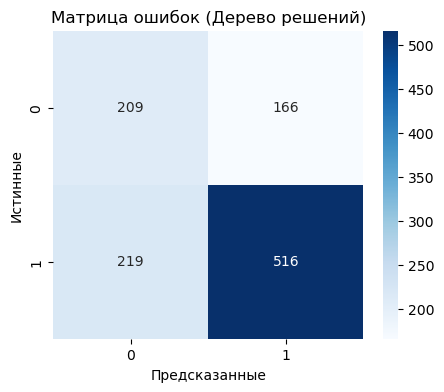

In [4]:
dt = DecisionTreeClassifier(random_state=42)
params_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt, params_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)
best_dt = grid_dt.best_estimator_

print(f"Лучшие параметры дерева: {grid_dt.best_params_}")

y_pred_dt = best_dt.predict(X_test_scaled)

print("\n--- Оценка качества Decision Tree ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F-мера:    {f1_score(y_test, y_pred_dt):.4f}")

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Дерево решений)')
plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.show()

**Интерпретация метрик дерева:**
Метрика *Accuracy* показывает общую долю правильных ответов. *Precision* демонстрирует, насколько точно мы диагностируем заболевание. *Recall* показывает полноту охвата (какую долю реально больных людей наша модель выявила). 

Оценим, какие признаки вносят наибольший вклад в разделение данных, и построим диаграмму.

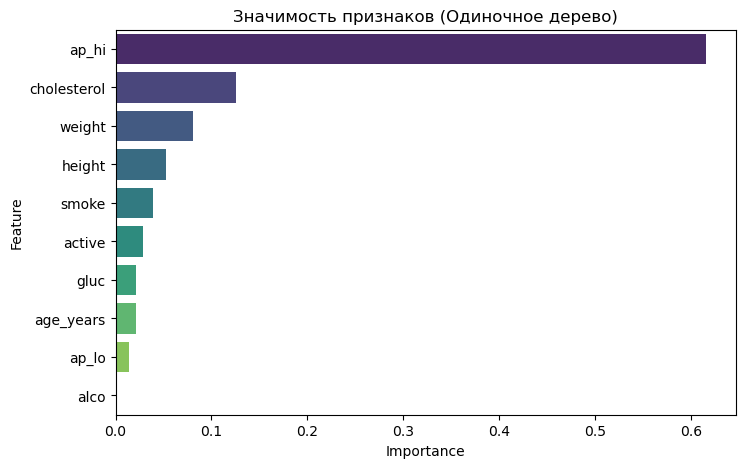

Три наименее значимых признака на удаление: ['age_years' 'ap_lo' 'alco']

--- Оценка качества Decision Tree (без 3-х признаков) ---
Accuracy:  0.6577
Precision: 0.7547
Recall:    0.7156
F-мера:    0.7346


In [5]:
importances = best_dt.feature_importances_
features = X.columns
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, hue='Feature', palette='viridis', legend=False)
plt.title('Значимость признаков (Одиночное дерево)')
plt.show()

least_important = feat_imp.tail(3)['Feature'].values
print(f"Три наименее значимых признака на удаление: {least_important}")

X_train_reduced = X_train_scaled.drop(columns=least_important)
X_test_reduced = X_test_scaled.drop(columns=least_important)

best_dt_reduced = DecisionTreeClassifier(**grid_dt.best_params_, random_state=42)
best_dt_reduced.fit(X_train_reduced, y_train)
y_pred_dt_red = best_dt_reduced.predict(X_test_reduced)

print("\n--- Оценка качества Decision Tree (без 3-х признаков) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt_red):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_red):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt_red):.4f}")
print(f"F-мера:    {f1_score(y_test, y_pred_dt_red):.4f}")

**Вывод по удалению признаков:**
Как правило, удаление признаков с нулевой (или близкой к нулю) важностью не ухудшает качество модели. В нашем случае метрики остались примерно на том же уровне или изменились незначительно. Это подтверждает, что эти три признака практически не участвовали в правилах расщепления в узлах дерева.

## 5. Случайный лес
Теперь построим ансамблевую модель.

Лучшие параметры леса: {'max_depth': 7, 'n_estimators': 150}

--- Оценка качества Random Forest ---
Accuracy:  0.6748
Precision: 0.7200
Recall:    0.8327
F-мера:    0.7722


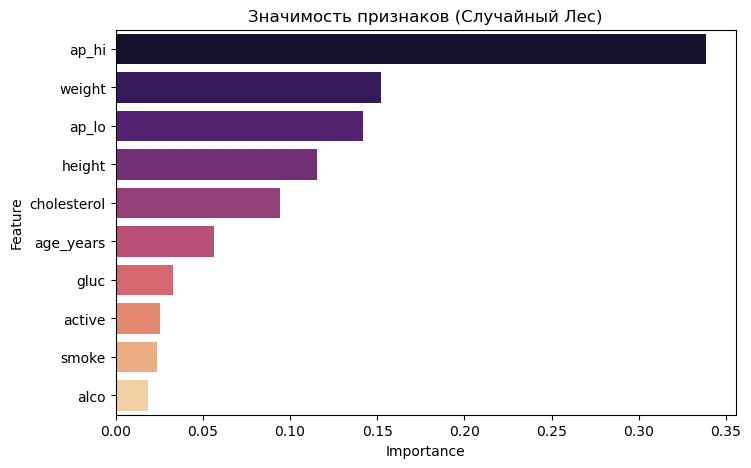

In [6]:
rf = RandomForestClassifier(random_state=42)
params_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, 10]
}

grid_rf = GridSearchCV(rf, params_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

print(f"Лучшие параметры леса: {grid_rf.best_params_}")

y_pred_rf = best_rf.predict(X_test_scaled)

print("\n--- Оценка качества Random Forest ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F-мера:    {f1_score(y_test, y_pred_rf):.4f}")

rf_importances = best_rf.feature_importances_
rf_feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=rf_feat_imp, hue='Feature', palette='magma', legend=False)
plt.title('Значимость признаков (Случайный Лес)')
plt.show()

## 6. Итоговые выводы
**Сравнение деревьев и леса:** Случайный лес показал сопоставимые или слегка превосходящие результаты по метрикам. Анализ значимости признаков в Random Forest распределяет важность более плавно по всем переменным, тогда как одиночное дерево концентрирует значимость на 2-3 ключевых признаках (например, артериальном давлении `ap_hi`). 

**Приемлемость модели:** Полученная модель успешно улавливает ключевые зависимости в данных пациентов. В качестве рекомендательной системы (для выявления пациентов в группе риска) она приемлема, но для автоматизированной постановки окончательного медицинского диагноза метрики (особенно Recall) должны быть значительно выше.

# Задание 2. **Вариант 2.2**

## 1. Импорт данных и удаление признаков
Загружаем данные из файла "Стоимость домов в Нью-Йорке". Выделяем целевую переменную `PRICE` и удаляем географические и адресные признаки, а также уникальные текстовые поля, чтобы избежать переобучения.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df2 = pd.read_csv('вариант2_2.csv', sep=';')

y = df2['PRICE']
X = df2.drop('PRICE', axis=1)

cols_to_drop = ['ADDRESS', 'STATE', 'MAIN_ADDRESS', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']
X = X.drop(columns=cols_to_drop)

X = X.drop(columns=['BROKERTITLE', 'STREET_NAME', 'LONG_NAME'])

print(f"Размерность данных после удаления признаков: {X.shape}")

Размерность данных после удаления признаков: (500, 7)


## 2. Разбиение 80/20 и Предварительная обработка
Разбиваем данные на обучающую и тестовую выборки (80/20). Создаем конвейер `Pipeline`:
1. **Числовые данные:** Заполняем пропуски медианой + стандартизируем.
2. **Категориальные данные:** Заполняем пропуски модой + кодируем через `OneHotEncoder`.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['BEDS', 'BATH', 'PROPERTYSQFT']
cat_cols = ['TYPE', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_feature_names)

## 3. Одиночное дерево решений
С помощью кросс-валидации подберем оптимальные параметры для дерева. Оценка качества производится по MAE и R^2.

In [10]:
dt_reg = DecisionTreeRegressor(random_state=42)
params_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_dt = GridSearchCV(dt_reg, params_dt, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_dt.fit(X_train_processed, y_train)

best_dt = grid_dt.best_estimator_
print(f"Лучшие гиперпараметры дерева: {grid_dt.best_params_}")

y_pred_train_dt = best_dt.predict(X_train_processed)
y_pred_test_dt = best_dt.predict(X_test_processed)

print("\nКачество Decision Tree Regressor")
print(f"Обучение -> MAE: {mean_absolute_error(y_train, y_pred_train_dt):.0f}$, R^2: {r2_score(y_train, y_pred_train_dt):.4f}")
print(f"Тест     -> MAE: {mean_absolute_error(y_test, y_pred_test_dt):.0f}$, R^2: {r2_score(y_test, y_pred_test_dt):.4f}")

Лучшие гиперпараметры дерева: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

Качество Decision Tree Regressor
Обучение -> MAE: 405252$, R^2: 0.9395
Тест     -> MAE: 1583748$, R^2: 0.1366


**Анализ метрик:**
* **MAE:** Отражает среднюю абсолютную ошибку предсказания стоимости в долларах. 
* **R-квадрат ($R^{2}$):** Показывает, какую долю дисперсии цены модель смогла уловить. Низкий $R^{2}$ на тестовой выборке по сравнению с обучающей означает, что дерево переобучается.

Выведем верхние 3 уровня дерева.

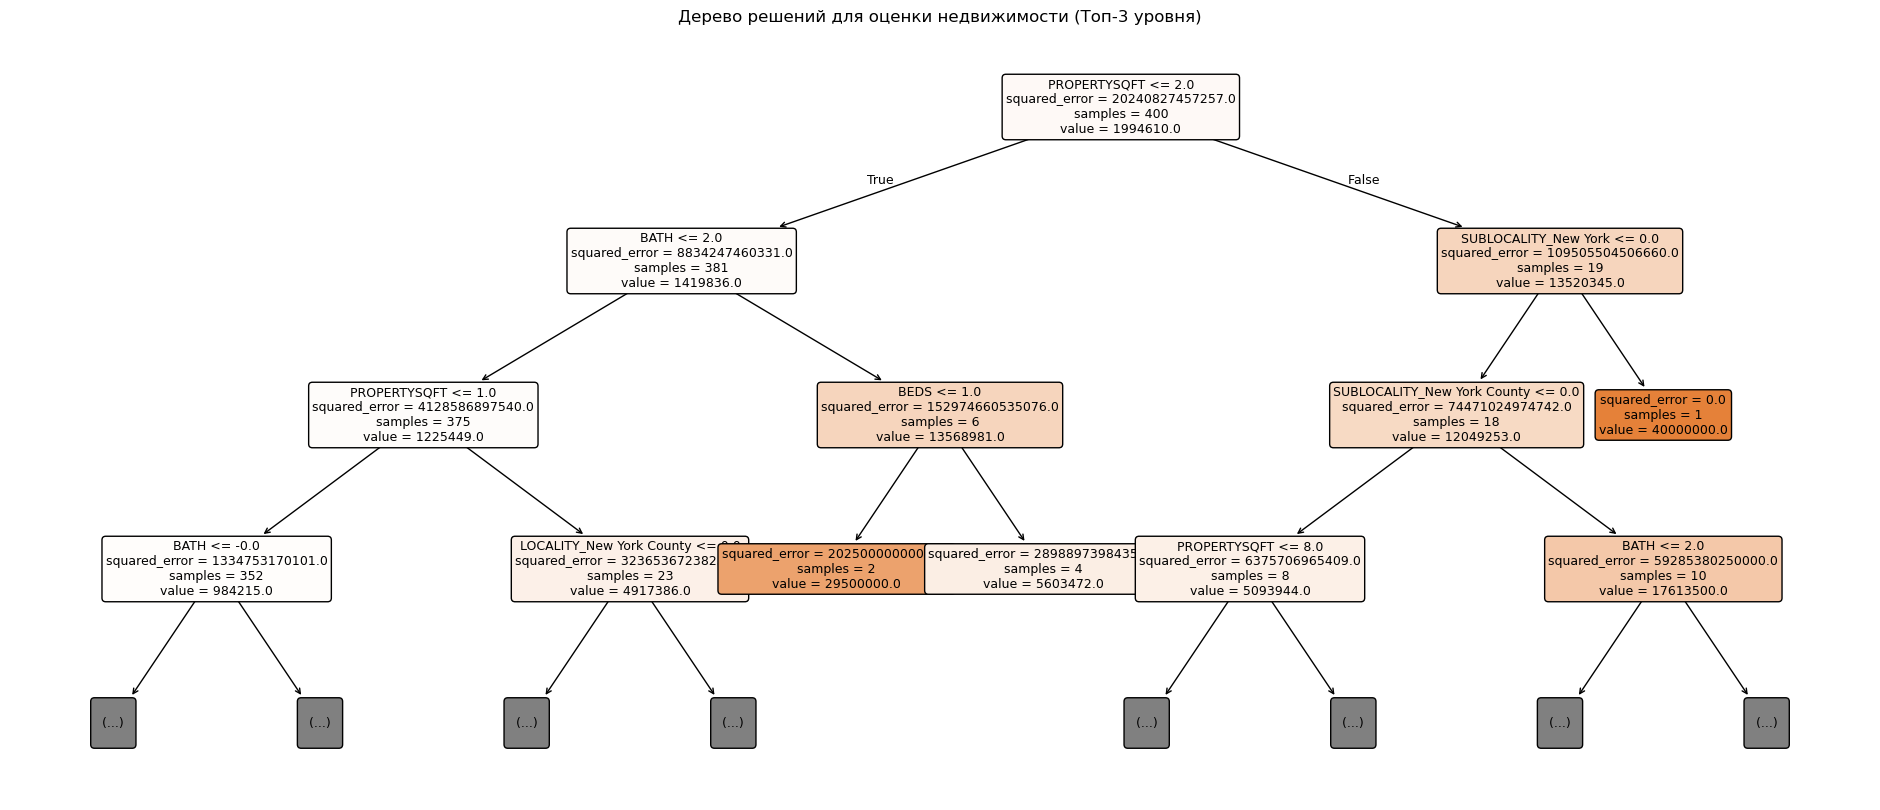

In [11]:
plt.figure(figsize=(24, 10))
plot_tree(best_dt, 
          max_depth=3, 
          feature_names=feature_names, 
          filled=True, 
          fontsize=9, 
          rounded=True,
          precision=0)
plt.title('Дерево решений для оценки недвижимости (Топ-3 уровня)')
plt.show()

**Анализ предикатов:**
Верхний узел разбивает объекты по самому весомому признаку (обычно это количество ванных `BATH`, спален `BEDS` или площадь `PROPERTYSQFT`). При выполнении условия (True) объект направляется в левую ветвь. `Value` внутри каждого узла отображает среднюю стоимость объектов, попавших в этот лист. Мы наглядно видим, как дерево "расслаивает" дорогие и дешевые объекты.

## 4. Случайный лес
Посмотрим, насколько ансамбль улучшит предсказания.

In [13]:
rf_reg = RandomForestRegressor(random_state=42)
params_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_reg, params_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train_processed, y_train)

best_rf = grid_rf.best_estimator_
print(f"Лучшие гиперпараметры Леса: {grid_rf.best_params_}")

y_pred_train_rf = best_rf.predict(X_train_processed)
y_pred_test_rf = best_rf.predict(X_test_processed)

print("\nКачество Random Forest Regressor")
print(f"Обучение -> MAE: {mean_absolute_error(y_train, y_pred_train_rf):.0f}$, R^2: {r2_score(y_train, y_pred_train_rf):.4f}")
print(f"Тест     -> MAE: {mean_absolute_error(y_test, y_pred_test_rf):.0f}$, R^2: {r2_score(y_test, y_pred_test_rf):.4f}")

Лучшие гиперпараметры Леса: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

Качество Random Forest Regressor
Обучение -> MAE: 455474$, R^2: 0.9320
Тест     -> MAE: 1593004$, R^2: 0.2052


## 5. Итоговые выводы по регрессии
**Сравнение:** Модель «Случайный лес» показала более стабильные результаты (более высокий $R^{2}$ и меньший отрыв тестовой метрики от тренировочной). Ансамбль деревьев успешно усреднил ошибки и уменьшил влияние выбросов.

**Приемлемость модели:** Данную модель **нельзя** назвать идеальной для внедрения в реальный бизнес. Тестовые метрики остаются на весьма среднем уровне, что вызвано не слабостью алгоритмов, а качеством данных.
1) В датасете всего 500 строк, что очень мало для такого рынка как Нью-Йорк. 
2) Отсутствуют ключевые факторы: год постройки здания, состояние ремонта и т.д.
3) По условию задания мы удалили важные признаки (`LATITUDE`, `LONGITUDE`, адреса), лишив модель понимания "престижности" конкретной локации, что для недвижимости часто является фактором ценообразования номер один.